# 13.3.1 局部恢复与吸引域

## 学习目标与先修知识

用小扰动速率与有限扰动返回区别两种韧性定义。

先修：4.1 吸引域（basin of attraction）、4.5 局部稳定性、2.4 数值步长。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

一个系统对微小扰动恢复很快，是否就能抵御一次较大扰动？局部恢复速度与能够返回的初态集合需要分开测量。

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

考虑正扰动 x，模型（model）右端为 −a x(1−x/B)。不计算轨迹（trajectory），先判断 0、B 处的平衡（equilibrium）及初态在 B 两侧时的方向。

In [2]:
for x in [.2,1.,1.4]:
    for B in [1.,2.]:
        print('x',x,'B',B,'变化率',round(-1.5*x*(1-x/B),3))

x 0.2 B 1.0 变化率 -0.24
x 0.2 B 2.0 变化率 -0.27
x 1.0 B 1.0 变化率 -0.0
x 1.0 B 2.0 变化率 -0.75
x 1.4 B 1.0 变化率 0.84
x 1.4 B 2.0 变化率 -0.63


## 模型假设

一维确定性教学模型，a>0、B>0、初态 x>0。0 是稳定参考状态（state），B 是正向扰动返回零的分界点。采用固定小步长显式 Euler 展示轨迹，并与局部解析指数参照。

## 数学解释与推导

$\dot x=-a x(1-x/B)$。在 0 附近 $f'(0)=-a$，所以小扰动近似 $x(t)\approx x_0e^{-at}$，局部恢复时间为 $1/a$。对正扰动 $0<x_0<B$，$\dot x<0$，轨迹朝 0；把平衡点本身也计入，非负侧的吸引域为 $[0,B)$。$x_0=B$ 为不稳定平衡；$x_0>B$ 时 $\dot x>0$，初始远离 0。改变 $B$ 而保持 $a$ 固定会改变可返回扰动范围，不改变 0 处的线性恢复率。数值轨迹还须检查步长，不能把大步长伪振荡当作系统动力学。 越过 B 后，方程给出持续向外的增长，并没有另一个有限稳定点。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def recovery_path(rate, boundary, initial, dt, steps):
    """Euler path for dx/dt=-rate*x*(1-x/boundary), positive initial only."""
    values = [float(initial)]
    for _ in range(steps):
        current = values[-1]
        values.append(current - dt * rate * current * (1 - current / boundary))
    return values

## 对照实验

固定 a=1.5，比较 B=1 与 B=2。分别从小扰动0.2和有限扰动1.4出发，在同一时间轴绘制短时轨迹。

C:\Users\10149\AppData\Local\Temp\ipykernel_66272\2933034849.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout();plt.show()


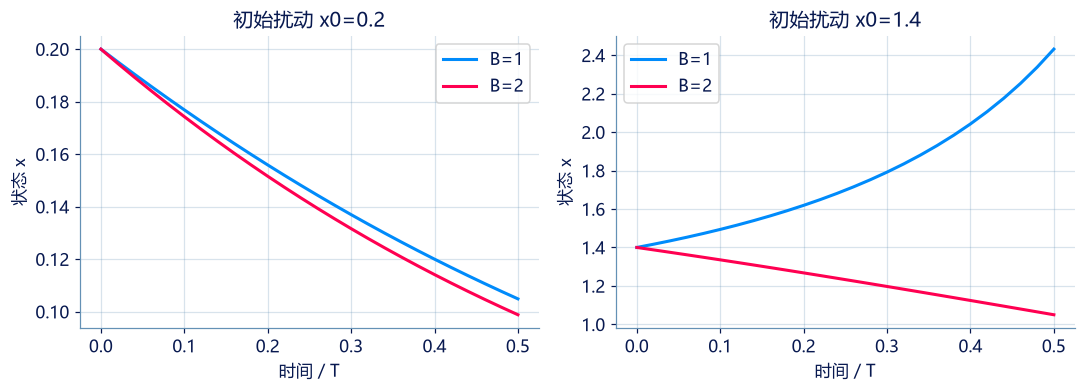

有限扰动末值： [(1.0, 2.4318582121544217), (2.0, 1.0499076561559915)]


In [4]:
rate=1.5;dt=.02;steps=25
fig,axes=plt.subplots(1,2,figsize=(10,3.7))
for ax,initial in zip(axes,[.2,1.4]):
    for B,color in [(1.,BLUE),(2.,PINK)]:
        values=recovery_path(rate,B,initial,dt,steps)
        ax.plot(np.arange(steps+1)*dt,values,label=f'B={B:g}',color=color)
    ax.set(xlabel='时间 / T',ylabel='状态 x',title=f'初始扰动 x0={initial}')
    ax.grid(alpha=.25);ax.legend()
plt.tight_layout();plt.show()
print('有限扰动末值：',[(B,recovery_path(rate,B,1.4,dt,steps)[-1]) for B in [1.,2.]])

## 结果解释

小扰动两条轨迹都下降，有限扰动却位于 B=1 的边界外、B=2 的边界内。这不冲突：恢复率是局部量，吸引域描述有限扰动去向。图中边界外的轨迹展示了离开原参考状态的短时趋势。

### 独立核对

直接代入 f'(0) 和 B 两侧的符号；用逐步细化核查小扰动数值结果。

In [5]:
for B in [1.,2.]:
    assert -rate*.2*(1-.2/B)<0
assert -rate*1.4*(1-1.4/1.)>0
assert -rate*1.4*(1-1.4/2.)<0
coarse=recovery_path(rate,2.,.001,.02,50)[-1]
fine=recovery_path(rate,2.,.001,.01,100)[-1]
exact=.001*math.exp(-rate)
assert abs(fine-exact)<abs(coarse-exact)
print('局部率、吸引域方向和步长细化通过。')

局部率、吸引域方向和步长细化通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/13-03-%E6%89%B0%E5%8A%A8%E3%80%81%E6%81%A2%E5%A4%8D%E4%B8%8E%E6%97%A9%E6%9C%9F%E9%A2%84%E8%AD%A6/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：计算扰动后的返回轨迹

模型（model） dx/dt=-rate*x*(1-x/boundary)，0 是稳定平衡（equilibrium），正 boundary 是吸引域（basin of attraction）边界。用显式 Euler 从 initial 更新 steps 次，返回包含初值（initial condition）的完整轨迹（trajectory）。

**函数与代码模板**

```python
def solve(
    rate: float,
    boundary: float,
    initial: float,
    dt: float,
    steps: int,
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `rate` | `float` | 局部恢复率（local recovery rate），正数。 | 1/T |
| `boundary` | `float` | 正向吸引域边界，正数。 | 状态单位 |
| `initial` | `float` | 正向初始扰动。 | 状态单位 |
| `dt` | `float` | 时间步长（time step）。 | T |
| `steps` | `int` | 更新步数。 | 步 |

**返回值**

直接返回 path（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `path` | `list[float]` | 每个时间点的状态（state）值，含初值。 | 状态单位 |

**计算规则**

按题定右端逐步更新；不要把局部线性指数解代替非线性有限扰动轨迹。

**约束与边界**

- 所有比较使用题定模型和相同单位；仅输出（output）函数返回值，不依赖外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| rate | 局部恢复率（local recovery rate），正数。 | 2 | 1/T |
| boundary | 正向吸引域边界，正数。 | 1 | 状态单位 |
| initial | 正向初始扰动。 | 0.2 | 状态单位 |
| dt | 时间步长（time step）。 | 0.1 | T |
| steps | 更新步数。 | 2 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
rate = 2.0
boundary = 1.0
initial = 0.2
dt = 0.1
steps = 2

result = solve(rate, boundary, initial, dt, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| path | 每个时间点的状态（state）值，含初值。 | [0.2, 0.168, 0.1400448] | 状态单位 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.2, 0.168, 0.1400448]
```

**样例解释**

小正扰动朝0返回；超过边界的正扰动先远离0，不能把局部速率外推至全域。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：计算扰动后的返回轨迹](http://127.0.0.1:8000/chapters/13-03-%E6%89%B0%E5%8A%A8%E3%80%81%E6%81%A2%E5%A4%8D%E4%B8%8E%E6%97%A9%E6%9C%9F%E9%A2%84%E8%AD%A6/practice/?question=p13-recovery-trajectory)

### 第 2 题 · 单项选择题：恢复率和吸引域不同

在 dx/dt=-rate*x*(1-x/boundary) 中，让 rate 固定而 boundary 从1改为2。哪项正确？

- **A.** 0附近线性恢复率不变，正向吸引域（basin of attraction）边界改变。
- **B.** 局部恢复率（local recovery rate）翻倍。
- **C.** 所有超过原边界的扰动都仍不返回。
- **D.** 两个概念完全等价。

[作答：恢复率和吸引域不同](http://127.0.0.1:8000/chapters/13-03-%E6%89%B0%E5%8A%A8%E3%80%81%E6%81%A2%E5%A4%8D%E4%B8%8E%E6%97%A9%E6%9C%9F%E9%A2%84%E8%AD%A6/practice/?question=p13-local-rate-vs-basin)

### 第 3 题 · 单项选择题：有限扰动不能只看斜率

同一个稳定平衡（equilibrium）附近的线性化（linearization）给出恢复时间约1/rate。要判断 x0=1.4 是否返回，还需要什么？

- **A.** 非线性方程及吸引域（basin of attraction）边界。
- **B.** 只知道 f'(0) 的符号。
- **C.** 只看采样（sampling）噪声方差（variance）。
- **D.** 假定所有稳定平衡吸引全空间。

[作答：有限扰动不能只看斜率](http://127.0.0.1:8000/chapters/13-03-%E6%89%B0%E5%8A%A8%E3%80%81%E6%81%A2%E5%A4%8D%E4%B8%8E%E6%97%A9%E6%9C%9F%E9%A2%84%E8%AD%A6/practice/?question=p13-finite-perturbation)

### 第 4 题 · 单项选择题：数值返回也需核验

用显式 Euler 估计恢复时，观察到某个过大步长产生交替穿越0的轨迹（trajectory）。哪项合适？

- **A.** 减小步长并对照局部解析指数，再判断是否为模型（model）现象。
- **B.** 直接宣布系统有内在振荡。
- **C.** 只查看最后一个点的符号。
- **D.** 更换颜色即能消除数值误差（numerical error）。

[作答：数值返回也需核验](http://127.0.0.1:8000/chapters/13-03-%E6%89%B0%E5%8A%A8%E3%80%81%E6%81%A2%E5%A4%8D%E4%B8%8E%E6%97%A9%E6%9C%9F%E9%A2%84%E8%AD%A6/practice/?question=p13-recovery-euler-step)

**进一步阅读**

[Scheffer 等（2009）](https://www.nature.com/articles/nature08227)讨论临界转变预警的条件；本节先独立定义恢复与扰动边界。